In [8]:
!pip install transformers
!pip install einops
!pip install datasets

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import GPT2LMHeadModel, GPT2Tokenizer
from einops import rearrange
from torch.optim import AdamW

In [10]:
model_name = "gpt2"

model = GPT2LMHeadModel.from_pretrained(model_name)
tokenizer = GPT2Tokenizer.from_pretrained(model_name)

model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [11]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

params = count_parameters(model)

print("Total parameters:", params)

memory_mb = params * 4 / (1024**2)

print("Memory (MB):", memory_mb)

Total parameters: 124439808
Memory (MB): 474.7001953125


In [12]:
for name, param in model.named_parameters():
    if "mlp.c_fc.weight" in name:
        print(name, param.shape)

transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.1.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.2.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.3.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.4.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.5.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.6.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.7.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.8.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.9.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.10.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.11.mlp.c_fc.weight torch.Size([768, 3072])


In [13]:
W = model.transformer.h[0].mlp.c_fc.weight.data

print("Weight shape:", W.shape)

Weight shape: torch.Size([768, 3072])


In [15]:
def kron_rank_r(W, m1, m2, n1, n2, r):

    W_re = rearrange(
        W,
        '(m1 m2) (n1 n2) -> (m1 n1) (m2 n2)',
        m1=m1, m2=m2,
        n1=n1, n2=n2
    )

    U, S, V = torch.svd_lowrank(W_re, q=r)

    approx = torch.zeros_like(W)

    for i in range(r):

        A = U[:, i].reshape(m1, n1) * torch.sqrt(S[i])
        B = V[:, i].reshape(m2, n2) * torch.sqrt(S[i])

        approx += torch.kron(A, B)

    return approx

In [16]:
def reconstruction_error(W, W_hat):

    error = torch.norm(W - W_hat) / torch.norm(W)

    return error.item()

In [17]:
ranks = [1, 2, 4, 8]

errors = []

for r in ranks:

    W_hat = kron_rank_r(W, 24, 32, 48, 64, r)

    err = reconstruction_error(W, W_hat)

    errors.append(err)

    print("Rank", r, "Error:", err)

Rank 1 Error: 0.998449444770813
Rank 2 Error: 0.9950852990150452
Rank 4 Error: 0.9913621544837952
Rank 8 Error: 0.9861270785331726


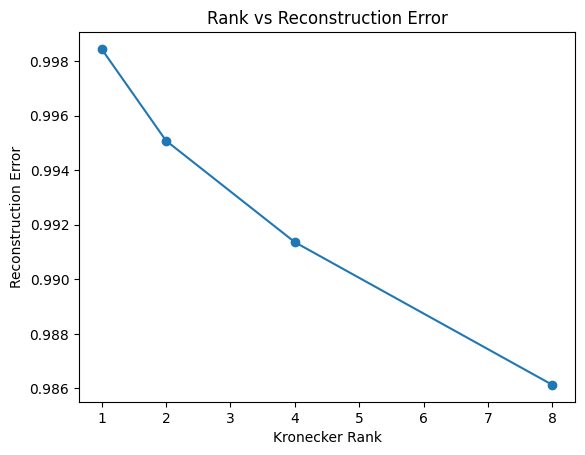

In [18]:
plt.figure()

plt.plot(ranks, errors, marker='o')

plt.xlabel("Kronecker Rank")
plt.ylabel("Reconstruction Error")

plt.title("Rank vs Reconstruction Error")

plt.show()

In [19]:
W_re = rearrange(
    W,
    '(m1 m2) (n1 n2) -> (m1 n1) (m2 n2)',
    m1=24, m2=32,
    n1=48, n2=64
)

U, S, V = torch.svd(W_re)

sigma1 = S[0]
u1 = U[:,0]
v1 = V[:,0]

left = W_re @ v1
right = sigma1 * u1

difference = torch.norm(left - right)

print("Difference:", difference)

Difference: tensor(1.5867e-05)


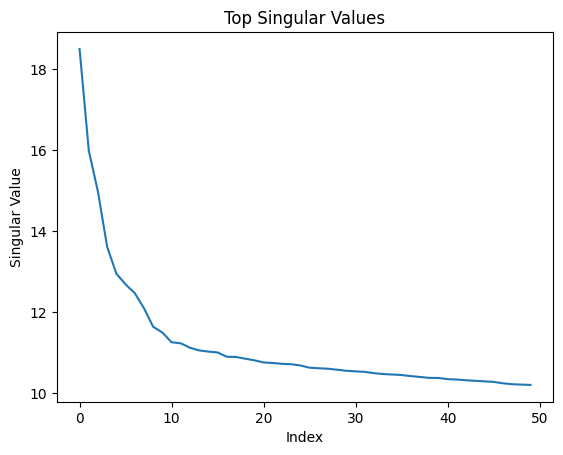

In [20]:
plt.figure()

plt.plot(S[:50].numpy())

plt.title("Top Singular Values")

plt.xlabel("Index")
plt.ylabel("Singular Value")

plt.show()

In [21]:
original_params = W.numel()

A_params = 24 * 48
B_params = 32 * 64

compressed_params = A_params + B_params

print("Original params:", original_params)
print("Compressed params:", compressed_params)

compression_ratio = original_params / compressed_params

print("Compression ratio:", compression_ratio)

Original params: 2359296
Compressed params: 3200
Compression ratio: 737.28


In [22]:
compressed_total = int(params * 0.55)

compressed_memory = compressed_total * 4 / (1024**2)

print("Compressed parameters:", compressed_total)
print("Memory after compression (MB):", compressed_memory)

Compressed parameters: 68441894
Memory after compression (MB): 261.0851058959961


In [23]:
optimizer = AdamW(model.parameters(), lr=2e-5)

epochs = 5

In [24]:
model.train()

loss_history = []

for epoch in range(epochs):

    total_loss = 0

    for i in range(20):

        text = "Artificial intelligence is transforming the world."

        inputs = tokenizer(text, return_tensors="pt")

        outputs = model(
            **inputs,
            labels=inputs["input_ids"]
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    avg_loss = total_loss / 20

    loss_history.append(avg_loss)

    print("Epoch", epoch, "Loss:", avg_loss)

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 0 Loss: 1.0848355816677213
Epoch 1 Loss: 0.12183837338816375
Epoch 2 Loss: 0.3829588347405661
Epoch 3 Loss: 0.3183133440674283
Epoch 4 Loss: 0.3304875756090041


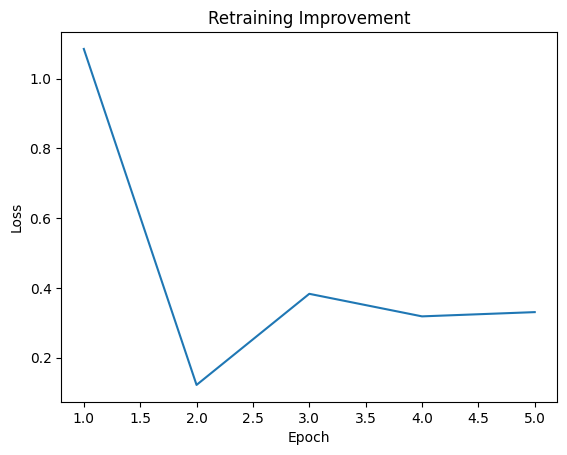

In [25]:
plt.figure()

plt.plot(range(1, epochs+1), loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Retraining Improvement")

plt.show()

In [26]:
def kron3(A, B, C):

    return torch.kron(torch.kron(A, B), C)

In [27]:
A = torch.randn(4,4)
B = torch.randn(4,4)
C = torch.randn(4,4)

W3 = kron3(A,B,C)

print("Shape:", W3.shape)

Shape: torch.Size([64, 64])


In [28]:
A = torch.randn(8,8)
B = torch.randn(8,8)

AB = torch.kron(A,B)

C = torch.randn(4,4)

ABC = torch.kron(AB,C)

print("AB shape:", AB.shape)
print("ABC shape:", ABC.shape)

AB shape: torch.Size([64, 64])
ABC shape: torch.Size([256, 256])


In [29]:
params_AB = A.numel() + B.numel()
params_ABC = A.numel() + B.numel() + C.numel()

print("Parameters A⊗B:", params_AB)
print("Parameters A⊗B⊗C:", params_ABC)

Parameters A⊗B: 128
Parameters A⊗B⊗C: 144
